In [1]:
import numpy as np

In [2]:
import pandas as pd
data = pd.read_csv('train.csv')

In [3]:
from pandas.core.frame import DataFrame
df = DataFrame(data)
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


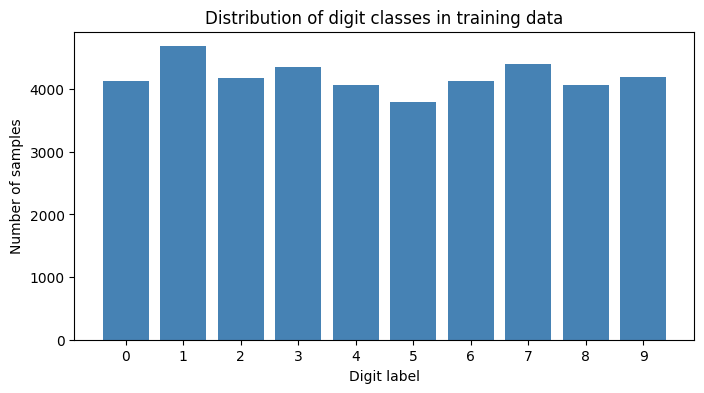

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64


In [4]:
import matplotlib.pyplot as plt

class_counts = df['label'].value_counts().sort_index()
plt.figure(figsize=(8, 4))
plt.bar(class_counts.index, class_counts.values, color='steelblue')
plt.xlabel('Digit label')
plt.ylabel('Number of samples')
plt.title('Distribution of digit classes in training data')
plt.xticks(range(10))
plt.show()

print(class_counts)

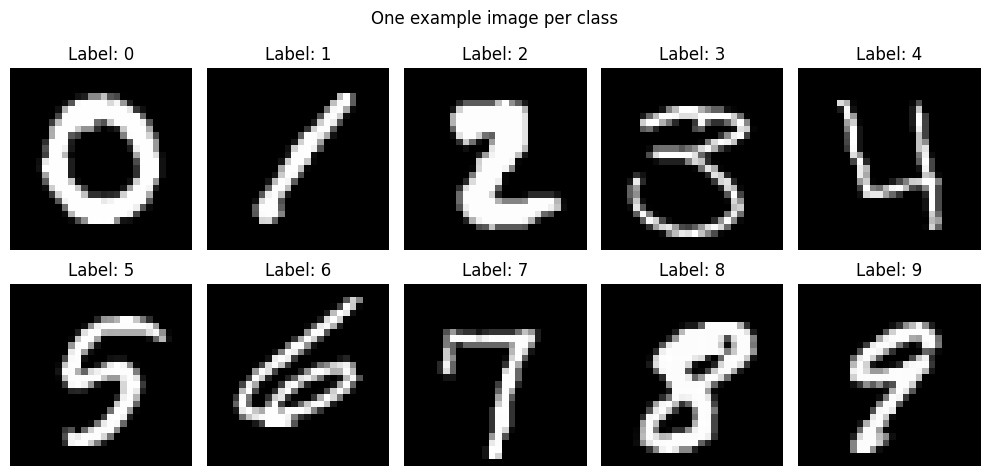

In [5]:
# Visualize a few representative images for each digit class
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    sample = df[df['label'] == digit].iloc[0, 1:].values.reshape(28, 28)
    ax.imshow(sample, cmap='gray')
    ax.set_title(f"Label: {digit}")
    ax.axis('off')
plt.suptitle('One example image per class')
plt.tight_layout()
plt.show()

In [10]:
df_arr = np.array(df)
m, n = df_arr.shape
np.random.shuffle(df_arr)

data_dev = df_arr[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n] / 255.0

data_train = df_arr[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n] / 255.0

print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_dev:  ", X_dev.shape, "Y_dev:  ", Y_dev.shape)

X_train: (784, 41000) Y_train: (41000,)
X_dev:   (784, 1000) Y_dev:   (1000,)


In [17]:
def params(hidden_size=10):
    w1 = np.random.randn(hidden_size, 784) * np.sqrt(2. / 784)
    b1 = np.zeros((hidden_size, 1))
    w2 = np.random.randn(10, hidden_size) * np.sqrt(2. / hidden_size)
    b2 = np.zeros((10, 1))
    return w1, b1, w2, b2


def ReLu(z):
    return np.maximum(0, z)


def softmax(z):
    A = np.exp(z - np.max(z, axis=0, keepdims=True))
    return A / np.sum(A, axis=0, keepdims=True)


def forward_prop(w1, b1, w2, b2, X):
    z1 = w1.dot(X) + b1
    A1 = ReLu(z1)
    z2 = w2.dot(A1) + b2
    A2 = softmax(z2)
    return z1, A1, z2, A2


def one_hot(Y, num_classes=10):
    one_hot_Y = np.zeros((Y.size, num_classes))
    one_hot_Y[np.arange(Y.size), Y.astype(int)] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y


def deriv_ReLu(z):
    return z > 0


def back_prop(z1, A1, z2, A2, w2, X, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)
    dz2 = A2 - one_hot_Y
    dw2 = (1 / m) * dz2.dot(A1.T)
    db2 = (1 / m) * np.sum(dz2, axis=1, keepdims=True)
    dz1 = w2.T.dot(dz2) * deriv_ReLu(z1)
    dw1 = (1 / m) * dz1.dot(X.T)
    db1 = (1 / m) * np.sum(dz1, axis=1, keepdims=True)
    return dw1, db1, dw2, db2


def update_params(w1, b1, w2, b2, dw1, db1, dw2, db2, lr):
    w1 = w1 - lr * dw1
    b1 = b1 - lr * db1
    w2 = w2 - lr * dw2
    b2 = b2 - lr * db2
    return w1, b1, w2, b2

In [ ]:
def compute_loss(A2, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)
    eps = 1e-9
    return -np.sum(one_hot_Y * np.log(A2 + eps)) / m


def get_predictions(A2):
    return np.argmax(A2, 0)


def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

In [19]:
def mini_batch_gradient_descent(X, Y, X_val, Y_val, hidden_size, epochs, batch_size, lr, verbose_every=5):
    w1, b1, w2, b2 = params(hidden_size)
    m = X.shape[1]
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        perm = np.random.permutation(m)
        X_shuffled = X[:, perm]
        Y_shuffled = Y[perm]

        for start in range(0, m, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[:, start:end]
            Y_batch = Y_shuffled[start:end]

            z1, A1, z2, A2 = forward_prop(w1, b1, w2, b2, X_batch)
            dw1, db1, dw2, db2 = back_prop(z1, A1, z2, A2, w2, X_batch, Y_batch)
            w1, b1, w2, b2 = update_params(w1, b1, w2, b2, dw1, db1, dw2, db2, lr)

        # Evaluate at the end of each epoch
        _, _, _, A2_train = forward_prop(w1, b1, w2, b2, X)
        train_loss = compute_loss(A2_train, Y)
        train_acc = get_accuracy(get_predictions(A2_train), Y)

        _, _, _, A2_val = forward_prop(w1, b1, w2, b2, X_val)
        val_loss = compute_loss(A2_val, Y_val)
        val_acc = get_accuracy(get_predictions(A2_val), Y_val)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if epoch % verbose_every == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
                  f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    return w1, b1, w2, b2, history

In [20]:
experiment_configs = [
    {"name": "Exp1: hidden=10, lr=0.1, batch=64",  "hidden_size": 10, "lr": 0.1, "batch_size": 64,  "epochs": 40},
    {"name": "Exp2: hidden=64, lr=0.1, batch=64",  "hidden_size": 64, "lr": 0.1, "batch_size": 64,  "epochs": 40},
    {"name": "Exp3: hidden=64, lr=0.5, batch=128", "hidden_size": 64, "lr": 0.5, "batch_size": 128, "epochs": 40},
]

results = {}
trained_params = {}

for cfg in experiment_configs:
    print("=" * 60)
    print(cfg["name"])
    print("=" * 60)
    w1, b1, w2, b2, history = mini_batch_gradient_descent(
        X_train, Y_train, X_dev, Y_dev,
        hidden_size=cfg["hidden_size"],
        epochs=cfg["epochs"],
        batch_size=cfg["batch_size"],
        lr=cfg["lr"],
    )
    results[cfg["name"]] = history
    trained_params[cfg["name"]] = (w1, b1, w2, b2)
    print(f"Final val accuracy: {history['val_acc'][-1]:.4f}\n")

Exp1: hidden=10, lr=0.1, batch=64
Epoch   0 | train_loss=0.3743 train_acc=0.8904 | val_loss=0.3259 val_acc=0.9100
Epoch   5 | train_loss=0.2283 train_acc=0.9342 | val_loss=0.2190 val_acc=0.9360
Epoch  10 | train_loss=0.1941 train_acc=0.9440 | val_loss=0.2037 val_acc=0.9410
Epoch  15 | train_loss=0.1947 train_acc=0.9432 | val_loss=0.2281 val_acc=0.9370
Epoch  20 | train_loss=0.1772 train_acc=0.9477 | val_loss=0.2056 val_acc=0.9480
Epoch  25 | train_loss=0.1613 train_acc=0.9535 | val_loss=0.1979 val_acc=0.9530
Epoch  30 | train_loss=0.1555 train_acc=0.9544 | val_loss=0.1999 val_acc=0.9500
Epoch  35 | train_loss=0.1556 train_acc=0.9545 | val_loss=0.2010 val_acc=0.9450
Epoch  39 | train_loss=0.1445 train_acc=0.9573 | val_loss=0.2014 val_acc=0.9500
Final val accuracy: 0.9500

Exp2: hidden=64, lr=0.1, batch=64
Epoch   0 | train_loss=0.2697 train_acc=0.9233 | val_loss=0.2433 val_acc=0.9340
Epoch   5 | train_loss=0.1103 train_acc=0.9682 | val_loss=0.1210 val_acc=0.9590
Epoch  10 | train_loss=0

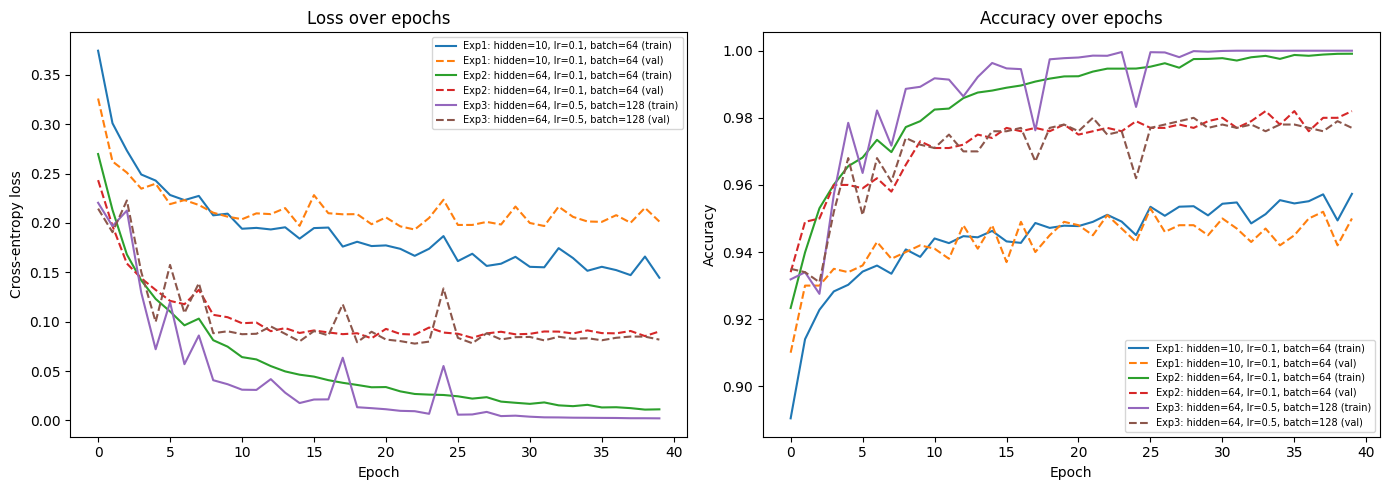

Exp1: hidden=10, lr=0.1, batch=64: final val_acc=0.9500, final val_loss=0.2014
Exp2: hidden=64, lr=0.1, batch=64: final val_acc=0.9820, final val_loss=0.0901
Exp3: hidden=64, lr=0.5, batch=128: final val_acc=0.9770, final val_loss=0.0818


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, history in results.items():
    axes[0].plot(history['train_loss'], label=f'{name} (train)')
    axes[0].plot(history['val_loss'], linestyle='--', label=f'{name} (val)')
    axes[1].plot(history['train_acc'], label=f'{name} (train)')
    axes[1].plot(history['val_acc'], linestyle='--', label=f'{name} (val)')

axes[0].set_title('Loss over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].legend(fontsize=7)

axes[1].set_title('Accuracy over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

for name, history in results.items():
    print(f"{name}: final val_acc={history['val_acc'][-1]:.4f}, final val_loss={history['val_loss'][-1]:.4f}")

In [22]:
best_name = max(results, key=lambda k: results[k]['val_acc'][-1])
w1, b1, w2, b2 = trained_params[best_name]
print("Best experiment:", best_name)

_, _, _, A2_dev = forward_prop(w1, b1, w2, b2, X_dev)
dev_predictions = get_predictions(A2_dev)
print("Dev accuracy:", get_accuracy(dev_predictions, Y_dev))

Best experiment: Exp2: hidden=64, lr=0.1, batch=64
Dev accuracy: 0.982


In [26]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(Y_dev, dev_predictions, digits=4))


              precision    recall  f1-score   support

           0     0.9813    1.0000    0.9906       105
           1     0.9908    1.0000    0.9954       108
           2     1.0000    0.9688    0.9841        96
           3     0.9829    0.9746    0.9787       118
           4     0.9775    0.9886    0.9831        88
           5     0.9884    0.9659    0.9770        88
           6     0.9821    0.9910    0.9865       111
           7     0.9889    0.9780    0.9834        91
           8     0.9659    0.9770    0.9714        87
           9     0.9633    0.9722    0.9677       108

    accuracy                         0.9820      1000
   macro avg     0.9821    0.9816    0.9818      1000
weighted avg     0.9821    0.9820    0.9820      1000



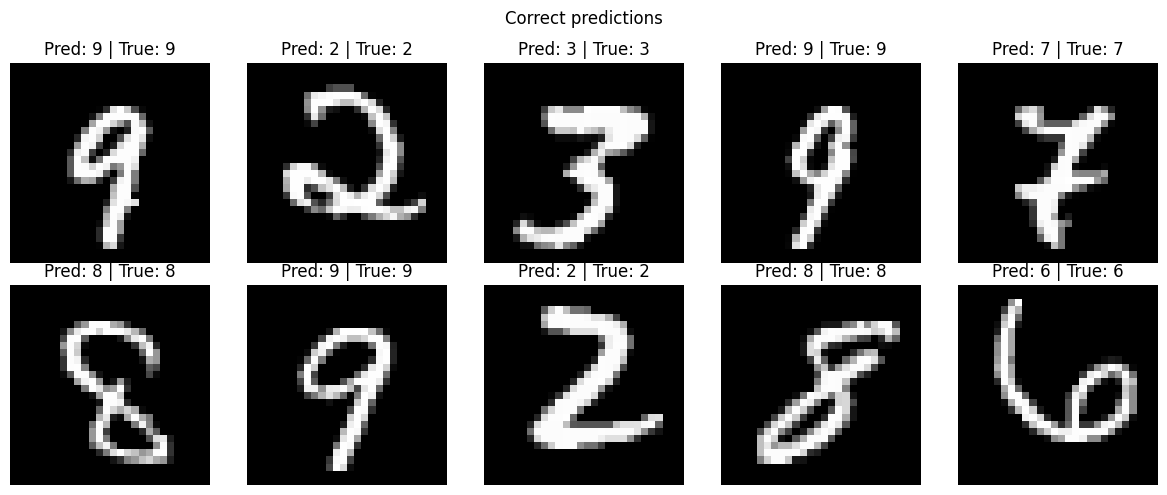

In [24]:
# Visualize a handful of correct predictions
correct_idx = np.where(dev_predictions == Y_dev)[0][:10]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flatten(), correct_idx):
    img = X_dev[:, idx].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Pred: {dev_predictions[idx]} | True: {Y_dev[idx]}")
    ax.axis('off')
plt.suptitle('Correct predictions')
plt.tight_layout()
plt.show()

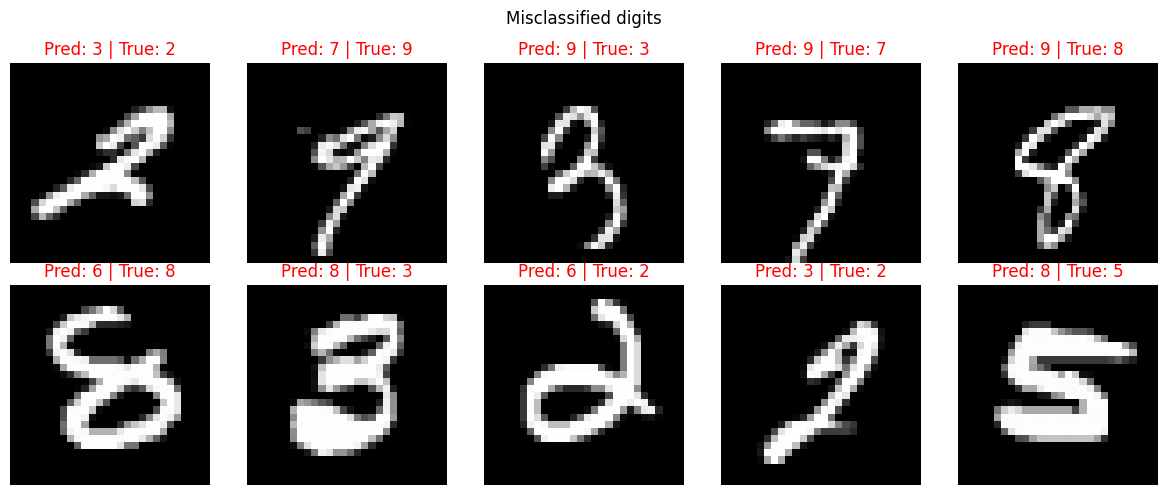

Misclassified: 18 / 1000


In [25]:
# Visualize misclassified digits
misclassified_idx = np.where(dev_predictions != Y_dev)[0][:10]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flatten(), misclassified_idx):
    img = X_dev[:, idx].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Pred: {dev_predictions[idx]} | True: {Y_dev[idx]}", color='red')
    ax.axis('off')
plt.suptitle('Misclassified digits')
plt.tight_layout()
plt.show()

print(f"Misclassified: {len(np.where(dev_predictions != Y_dev)[0])} / {Y_dev.size}")